In [3]:
from matplotlib import pyplot as plt
import numpy as np
import math
import sys
import random

In [4]:
np.set_printoptions(threshold=sys.maxsize)
plt.rcParams["figure.figsize"] = (5,5)

In [7]:
def do_add( spile, tumbled ):
    """ Updates spile in place """
    spile[ :-1, :] += tumbled[ 1:, :] # Shift N and add                 
    spile[ 1:, :] += tumbled[ :-1, :] # Shift S   
    spile[ :, :-1] += tumbled[ :, 1:] # Shift W
    spile[ :, 1:] += tumbled[ :, :-1] # Shift E

def tumble( spile ):
    while ( spile > 3 ).any():
        tumbled, spile = np.divmod( spile, 4 )
        do_add( spile, tumbled )
        # print( spile, '\n' )  # Uncomment to print steps
    return spile

In [159]:
size = 9

In [469]:
T = np.zeros((size,size), dtype='int')
C = np.zeros((size,size), dtype='int')
ND = np.zeros((size,size), dtype='int')
AC = np.zeros((size,size), dtype='int')



# 1 queen
# 2 N
# 3 D
# 4 A
# 5 C


C[size//2,size//2] = 1
C[-1,0] = 1
C[0,-1] = 1
C[0,0] = 4
C[-1,-1] = 5
ACs = np.where(C > 3)
for (y,x) in zip(ACs[0],ACs[1]):
    AC[y,x] = 1

oldAC = np.copy(AC)

a0 = 0.5
alpha = 1
gamma = 1
cAA = 1
cAC = 1
cCC = 0.5

nD = len(np.where(C == 3))
nA = len(np.where(C == 4))
nC = len(np.where(C == 5))


[[0 0 0 0 0 0 0 0 3]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [3 0 0 0 0 0 0 0 0]]
[[0 1 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0]]


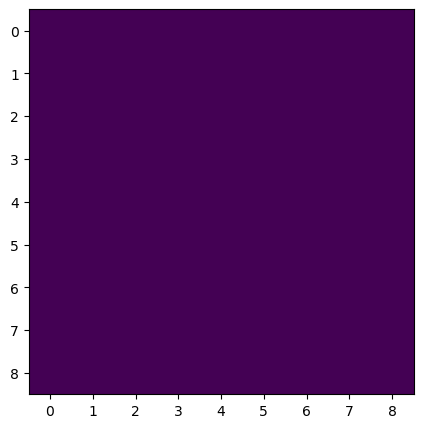

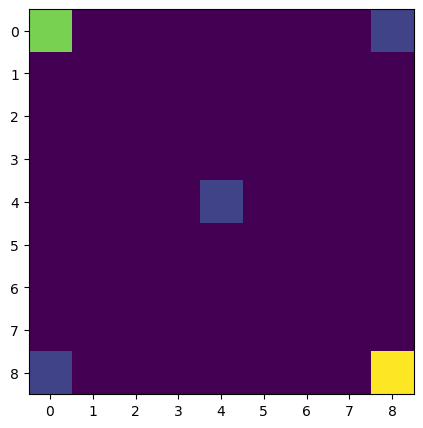

In [472]:
# tick

nD = len(np.where(C == 3))
nA = len(np.where(C == 4))
nC = len(np.where(C == 5))

# eating
As = np.where(C == 4)
for (y,x) in zip(As[0],As[1]):
    north = south = east = west = northeast = northwest = southeast = southwest = 0
    if y>=0:
        north = C[y-1,x]
    if y<size-1:
        south = C[y+1,x]
    if x<size-1:
        east = C[y,x+1]
    if x>=0:
        west = C[y,x-1]
    if y>=0 and x<size-1:
        northeast = C[y-1,x+1]
    if y>=0 and x>0:
        northwest = C[y-1,x-1]
    if y<size-1 and x<size-1:
        southeast = C[y+1,x+1]
    if y<size-1 and x>0:
        southwest = C[y+1,x-1]
    neighbors = [north, south, east, west, northeast, northwest, southeast, southwest]
    # can eat N, D
    for i, j in enumerate(neighbors):
        if j == 2:
            # conditions
            pkill = max(0, min(a0+alpha*nD / 1 + cAA*nA + cAC*nC, 1))
            if i == 0:
                # north
                C[y-1,x] = ND[y-1,x] = 0
            elif i == 1:
                # south
                C[y+1,x] = ND[y+1,x] = 0
            elif i == 2:
                # east
                C[y,x+1] = ND[y,x+1] = 0
            elif i == 3:
                # west
                C[y,x-1] = ND[y,x-1] = 0
            elif i == 4:
                # northeast
                C[y-1,x+1] = ND[y-1,x+1] = 0
            elif i == 5:
                # northwest
                C[y-1,x+1] = ND[y-1,x+1] = 0
            elif i == 6:
                # southeast
                C[y+1,x+1] = ND[y+1,x+1] = 0
            elif i == 7:
                # southwest
                C[y+1,x-1] = ND[y+1,x-1] = 0
        if j == 3:
            if 2 not in neighbours:
                if i == 0:
                    # north
                    C[y-1,x] = ND[y-1,x] = 0
                elif i == 1:
                    # south
                    C[y+1,x] = ND[y+1,x] = 0
                elif i == 2:
                    # east
                    C[y,x+1] = ND[y,x+1] = 0
                elif i == 3:
                    # west
                    C[y,x-1] = ND[y,x-1] = 0
                elif i == 4:
                    # northeast
                    C[y-1,x+1] = ND[y-1,x+1] = 0
                elif i == 5:
                    # northwest
                    C[y-1,x+1] = ND[y-1,x+1] = 0
                elif i == 6:
                    # southeast
                    C[y+1,x+1] = ND[y+1,x+1] = 0
                elif i == 7:
                    # southwest
                    C[y+1,x-1] = ND[y+1,x-1] = 0


Cs = np.where(C == 5)
for (y,x) in zip(Cs[0],Cs[1]):
    north = south = east = west = northeast = northwest = southeast = southwest = 0

    if y>=0:
        north = C[y-1,x]
    if y<size-1:
        south = C[y+1,x]
    if x<size-1:
        east = C[y,x+1]
    if x>=0:
        west = C[y,x-1]
    if y>=0 and x<size-1:
        northeast = C[y-1,x+1]
    if y>=0 and x>0:
        northwest = C[y-1,x-1]
    if y<size-1 and x<size-1:
        southeast = C[y+1,x+1]
    if y<size-1 and x>0:
        southwest = C[y+1,x-1]
    neighbors = [north, south, east, west, northeast, northwest, southeast, southwest]
    # can eat N, D
    for i, j in enumerate(neighbors):
        if j == 2:
            pkill = max(0, min(a0+alpha*nD / 1 + cCC - gamma*nC + cAC*nA, 1))
            if i == 0:
                # north
                C[y-1,x] = ND[y-1,x] = 0
            elif i == 1:
                # south
                C[y+1,x] = ND[y+1,x] = 0
            elif i == 2:
                # east
                C[y,x+1] = ND[y,x+1] = 0
            elif i == 3:
                # west
                C[y,x-1] = ND[y,x-1] = 0
            elif i == 4:
                # northeast
                C[y-1,x+1] = ND[y-1,x+1] = 0
            elif i == 5:
                # northwest
                C[y-1,x+1] = ND[y-1,x+1] = 0
            elif i == 6:
                # southeast
                C[y+1,x+1] = ND[y+1,x+1] = 0
            elif i == 7:
                # southwest
                C[y+1,x-1] = ND[y+1,x-1] = 0
        if j == 3:
            if 2 not in neighbours:
                if i == 0:
                    # north
                    C[y-1,x] = ND[y-1,x] = 0
                elif i == 1:
                    # south
                    C[y+1,x] = ND[y+1,x] = 0
                elif i == 2:
                    # east
                    C[y,x+1] = ND[y,x+1] = 0
                elif i == 3:
                    # west
                    C[y,x-1] = ND[y,x-1] = 0
                elif i == 4:
                    # northeast
                    C[y-1,x+1] = ND[y-1,x+1] = 0
                elif i == 5:
                    # northwest
                    C[y-1,x+1] = ND[y-1,x+1] = 0
                elif i == 6:
                    # southeast
                    C[y+1,x+1] = ND[y+1,x+1] = 0
                elif i == 7:
                    # southwest
                    C[y+1,x-1] = ND[y+1,x-1] = 0

# add new ND to C
NDs = np.where(abs(oldND-ND) > 0)
for (y,x) in zip(NDs[0],NDs[1]):
    if y%2==0:
        if C[y,x] != 1:
            C[y,x] = 2
    else:
        if C[y,x] != 1:
            C[y,x] = 3

# add new AC to C, don't occupy ND
ACs = np.where(abs(oldAC-AC) > 0)
for (y,x) in zip(ACs[0],ACs[1]):
    if y%2==0:
        if C[y,x] <= 0:
            C[y,x] = 4
        elif C[y,x]<4:
            AC[y,x] = 0
    else:
        if C[y,x] <= 0:
            C[y,x] = 5
        elif C[y,x]<4:
            AC[y,x] = 0

# new ND
Qs = np.where(C == 1)
for (y,x) in zip(Qs[0],Qs[1]):
    ND[y,x] = ND[y,x]+1

Ds = np.where(C == 3)

# AC increment age
ACs = np.where(AC > 0)
for (y,x) in zip(ACs[0],ACs[1]):
    AC[y,x] = AC[y,x]+1

Cs = np.where(C == 5)

oldND = np.copy(ND)
oldAC = np.copy(AC)
ND = tumble(ND)
AC = tumble(AC)
print(ND)
print(AC)
plt.imshow(T, interpolation='nearest');plt.show()
plt.imshow(C, interpolation='nearest');plt.show()

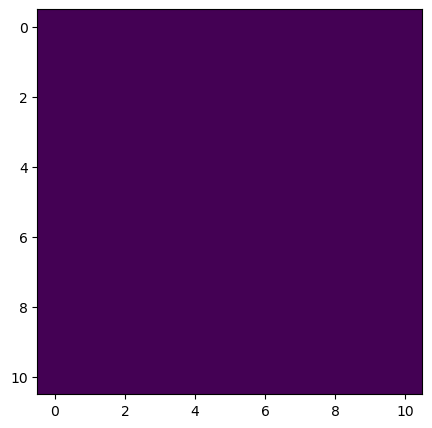

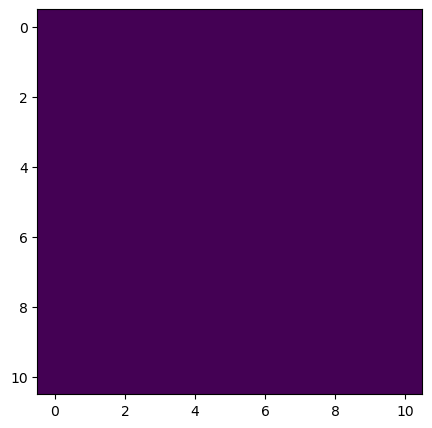

In [12]:
plt.imshow(T, interpolation='nearest');plt.show()
plt.imshow(C, interpolation='nearest');plt.show()